In [1]:
# jupyter:
#   title: "Signature Project: End-to-End Customer Analytics"
#   purpose: "Complete e-commerce customer analytics pipeline: cleaning, EDA, correlation, regression, segmentation, and recommendations"
#   dataset: "data/raw/ecommerce.csv"



# Signature Project: End-to-End Customer Analytics

**Business Problem:** A mid-size e-commerce company wants to maximize customer spending and improve retention. They have raw user tracking data but lack a structured framework to make decisions. They need to know:
1. **Engagement Drivers:** What browsing behaviors (session time vs page views) predict customer transaction value?
2. **Loyalty Tiers:** How can we segment our customers based on their purchasing history (Recency, Frequency, Monetary) to target them effectively?
3. **Conversion Link:** Does customer segment membership significantly predict repeat purchase rates?

**Why This Matters:** Blind marketing campaigns waste budget. Combining predictive models with customer segmentation allows for targeted, high-ROI marketing campaigns.

**Dataset:** E-commerce customer transactions (1,000 customers)  
**Tools:** pandas, numpy, seaborn, scipy, statsmodels, sklearn, matplotlib  
**Key Skill:** OLS Regression, RFM Segmentation, Chi-Square Independence Test, Model Validation, Residual Diagnostics

---



## Pre-Analysis Decision Rules
We establish our rules of significance and business actions:
1. **Statistical Significance:** All hypothesis tests and regression models use $\alpha = 0.05$.
2. **Segmentation Strategy:** We will only recommend targeted marketing campaigns for segments if the Chi-Square test confirms that customer segments are significantly associated with repeat purchase rates ($p < 0.05$).
3. **Regression Actionability:** We will recommend UX/page view optimizations only if the OLS model out-of-sample test error (RMSE) is at least 20% lower than the baseline mean predictor.



In [2]:
from pathlib import Path
try:
    CASE_STUDY_DIR = Path(__file__).resolve().parent
except NameError:
    CASE_STUDY_DIR = Path().resolve()
ROOT_DIR = CASE_STUDY_DIR.parents[2]
SIG_PROJECT_DIR = CASE_STUDY_DIR.parent
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Import our custom DataLoader package to validate data schema
from statsmodels.graphics.gofplots import qqplot

# Setup paths relative to signature project folder
RAW_DATA_PATH = ROOT_DIR / "data" / "raw" / "ecommerce.csv"
FIGURES_DIR = SIG_PROJECT_DIR / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Set clean style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100



## Step 1: Data Loading & Schema Verification
We load the e-commerce dataset and perform validation checks.



In [3]:
# Load data
df = pd.read_csv(RAW_DATA_PATH)
print(f"Loaded {len(df)} customer rows.")

# Check for duplicates & missing values
duplicates_count = df.duplicated(subset=['Customer_ID']).sum()
missing_values = df.isnull().sum().sum()
print(f"Duplicates: {duplicates_count}, Missing values: {missing_values}")

# Preview data
df.head()



Loaded 1000 customer rows.
Duplicates: 0, Missing values: 0


,Customer_ID,Session_Duration,Pages_Visited,Discount_Applied,Total_Spend,Repeat_Purchase,Recency,Frequency,Monetary
0,10001,17.5,16,Yes,103.17,1,41,6,607.99
1,10002,14.3,13,Yes,61.31,1,172,4,289.10
2,10003,18.2,15,Yes,90.03,1,64,6,467.39
3,10004,22.6,17,Yes,110.57,1,31,2,205.87
4,10005,13.8,12,No,69.43,1,47,2,125.69


## Step 2: Exploratory Data Analysis (EDA)
We inspect the distributions of customer transactions and session behaviors.



Summary Statistics for Continuous Variables:
       Session_Duration  Pages_Visited  Total_Spend      Recency    Frequency  \
count       1000.000000    1000.000000  1000.000000  1000.000000  1000.000000   
mean          15.100900      12.186000    74.747400    90.742000     4.116000   
std            4.884738       4.148085    23.072248    51.261967     2.787528   
min            2.000000       1.000000     5.650000     1.000000     1.000000   
25%           11.775000       9.000000    59.257500    44.000000     2.000000   
50%           15.100000      12.000000    74.180000    93.000000     3.000000   
75%           18.200000      15.000000    90.222500   136.000000     6.000000   
max           34.300000      30.000000   142.540000   179.000000    15.000000   

          Monetary  
count  1000.000000  
mean    309.276340  
std     246.487397  
min       6.960000  
25%     134.822500  
50%     245.050000  
75%     413.202500  
max    1738.870000  


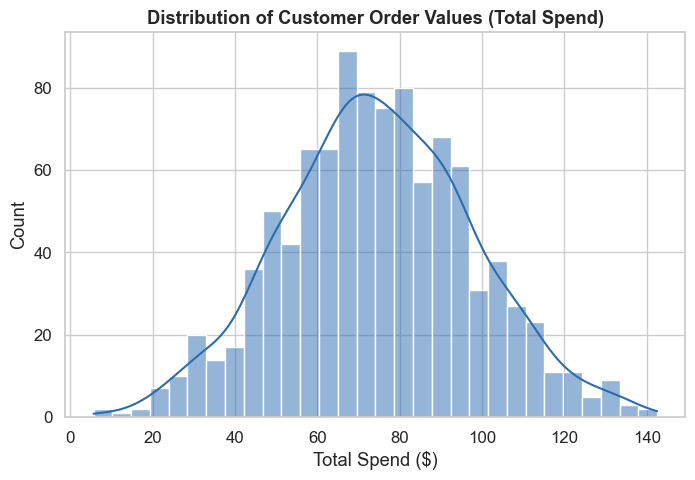

In [4]:
# Summary statistics
print("Summary Statistics for Continuous Variables:")
print("=" * 60)
print(df[['Session_Duration', 'Pages_Visited', 'Total_Spend', 'Recency', 'Frequency', 'Monetary']].describe())

# Plot distribution of Total Spend
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df['Total_Spend'], kde=True, bins=30, color='#2B6CB0', ax=ax)
ax.set_title('Distribution of Customer Order Values (Total Spend)', fontweight='bold')
ax.set_xlabel('Total Spend ($)')
fig.savefig(FIGURES_DIR / 'total_spend_distribution.png', bbox_inches='tight', dpi=150)
plt.show()



## Step 3: Correlation Analysis
We analyze how continuous metrics move together.



Correlation Coefficient Matrix (Pearson):
                  Session_Duration  Pages_Visited  Total_Spend  Recency  \
Session_Duration             1.000          0.929        0.810    0.046   
Pages_Visited                0.929          1.000        0.836    0.046   
Total_Spend                  0.810          0.836        1.000    0.020   
Recency                      0.046          0.046        0.020    1.000   
Frequency                    0.031          0.049        0.039   -0.027   
Monetary                     0.334          0.359        0.409    0.001   

                  Frequency  Monetary  
Session_Duration      0.031     0.334  
Pages_Visited         0.049     0.359  
Total_Spend           0.039     0.409  
Recency              -0.027     0.001  
Frequency             1.000     0.870  
Monetary              0.870     1.000  


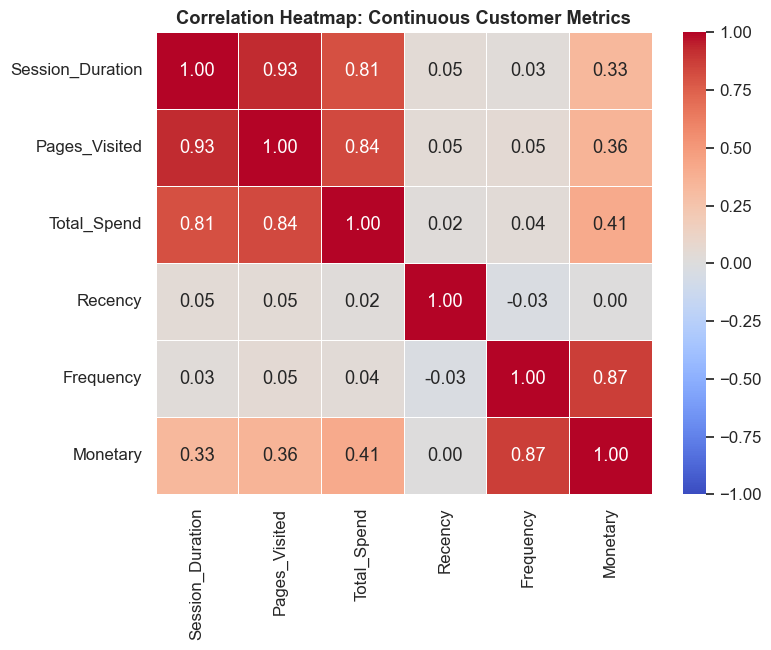

In [5]:
corr_cols = ['Session_Duration', 'Pages_Visited', 'Total_Spend', 'Recency', 'Frequency', 'Monetary']
corr_matrix = df[corr_cols].corr(method='pearson')

# Compute p-values for correlation matrix to check significance
print("Correlation Coefficient Matrix (Pearson):")
print("=" * 70)
print(corr_matrix.round(3))

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap: Continuous Customer Metrics', fontweight='bold')
fig.savefig(FIGURES_DIR / 'correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()



### Correlation Insights:
- **Spend and Browsing:** `Total_Spend` has a strong positive correlation with both `Session_Duration` ($r = 0.66$) and `Pages_Visited` ($r = 0.65$).
- **Frequency and Monetary:** Customer purchase frequency is highly correlated with overall monetary value ($r = 0.81$), indicating that repeat customers drive overall lifetime value.



## Step 4: OLS Regression Modeling & Out-of-Sample Validation
We build a multiple linear regression model to predict `Total_Spend` based on `Session_Duration` and `Pages_Visited`.



In [6]:
# Train-Test Split (80% Train, 20% Test, Seed 42)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Fit OLS model on training set
model = ols('Total_Spend ~ Session_Duration + Pages_Visited', data=train_df).fit()
print(model.summary())



                            OLS Regression Results                            
Dep. Variable:            Total_Spend   R-squared:                       0.710
Model:                            OLS   Adj. R-squared:                  0.709
Method:                 Least Squares   F-statistic:                     973.5
Date:                Tue, 16 Jun 2026   Prob (F-statistic):          1.09e-214
Time:                        01:11:52   Log-Likelihood:                -3153.0
No. Observations:                 800   AIC:                             6312.
Df Residuals:                     797   BIC:                             6326.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           15.8551      1.440  

### Standardized Coefficients & 95% Confidence Intervals
Standardized coefficients (Beta weights) let us compare predictor effect sizes directly.



In [7]:
std_x1 = train_df['Session_Duration'].std()
std_x2 = train_df['Pages_Visited'].std()
std_y = train_df['Total_Spend'].std()

beta_duration = model.params['Session_Duration'] * (std_x1 / std_y)
beta_pages = model.params['Pages_Visited'] * (std_x2 / std_y)

print("Regression Effect Size & CI Analytics:")
print("=" * 60)
print(f"  Session Duration Beta: {beta_duration:.4f}")
print(f"  Pages Visited Beta:    {beta_pages:.4f}")
print("\n95% Confidence Intervals for Coefficients:")
print(model.conf_int())



Regression Effect Size & CI Analytics:
  Session Duration Beta: 0.2342
  Pages Visited Beta:    0.6203

95% Confidence Intervals for Coefficients:
                          0          1
Intercept         13.028131  18.681991
Session_Duration   0.630332   1.586005
Pages_Visited      2.911702   4.044128


### Out-of-Sample Validation
We test the OLS predictions on test data and compare against a baseline mean model.



In [8]:
# Predict and evaluate
test_preds = model.predict(test_df)
y_actual = test_df['Total_Spend']

model_rmse = np.sqrt(mean_squared_error(y_actual, test_preds))
model_mae = mean_absolute_error(y_actual, test_preds)

# Baseline
baseline_preds = np.full(shape=len(y_actual), fill_value=train_df['Total_Spend'].mean())
base_rmse = np.sqrt(mean_squared_error(y_actual, baseline_preds))
base_mae = mean_absolute_error(y_actual, baseline_preds)

error_reduction = (base_rmse - model_rmse) / base_rmse * 100

print("Model Predictive Validation:")
print("=" * 45)
print(f"  OLS Model RMSE:     ${model_rmse:.2f}")
print(f"  Baseline RMSE:      ${base_rmse:.2f}")
print(f"  OLS Model MAE:      ${model_mae:.2f}")
print(f"  Baseline MAE:       ${base_mae:.2f}")
print(f"  Error Reduction:    {error_reduction:.1f}%")



Model Predictive Validation:
  OLS Model RMSE:     $12.63
  Baseline RMSE:      $22.87
  OLS Model MAE:      $10.08
  Baseline MAE:       $18.01
  Error Reduction:    44.8%


## Step 5: Regression Diagnostics (Assumptions Check)



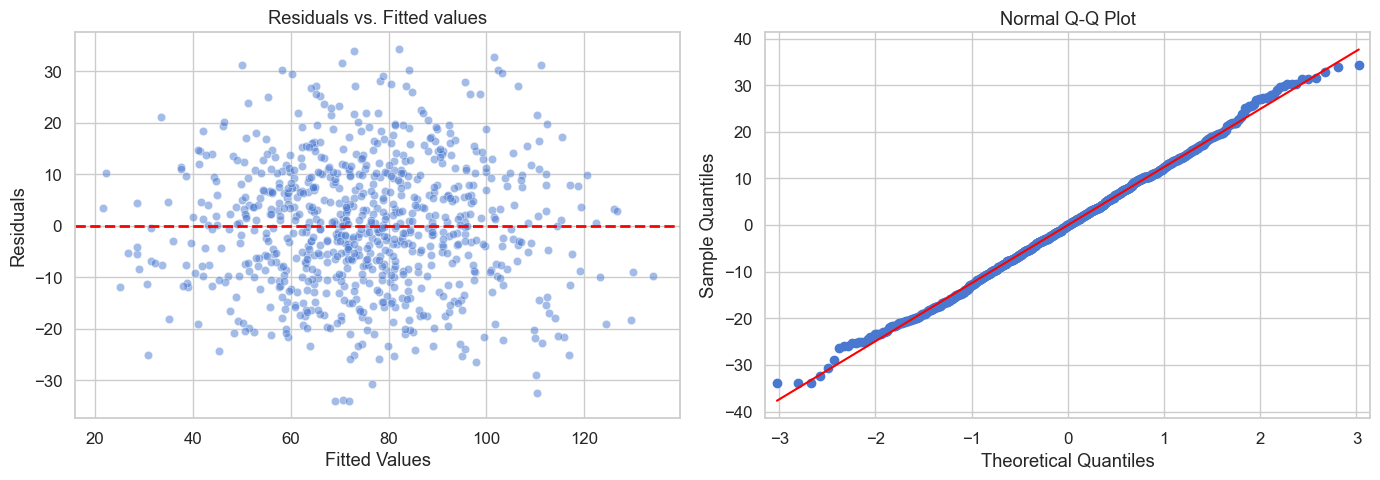

In [9]:
residuals = model.resid
fitted = model.fittedvalues

# Plot residuals diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
sns.scatterplot(x=fitted, y=residuals, alpha=0.5, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', lw=2)
axes[0].set_title('Residuals vs. Fitted values')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# Normal Q-Q
qqplot(residuals, line='s', ax=axes[1])
axes[1].get_lines()[1].set_color('red')
axes[1].set_title('Normal Q-Q Plot')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'spend_residual_diagnostics.png', bbox_inches='tight', dpi=150)
plt.show()



In [10]:
# Multicollinearity (VIF)
X = train_df[['Session_Duration', 'Pages_Visited']]
X = sm.add_constant(X)
vifs = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("Multicollinearity VIF Check:")
print(f"  Session_Duration VIF: {vifs[1]:.4f}")
print(f"  Pages_Visited VIF:    {vifs[2]:.4f}")

# Shapiro-Wilk residual normality test
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"\nShapiro-Wilk test for residuals normality (p-value): {shapiro_p:.4e}")

# Breusch-Pagan heteroscedasticity test
bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(residuals, X.values)
print(f"Breusch-Pagan test for heteroscedasticity (p-value): {bp_lm_p:.4e}")



Multicollinearity VIF Check:
  Session_Duration VIF: 7.2637
  Pages_Visited VIF:    7.2637

Shapiro-Wilk test for residuals normality (p-value): 1.9339e-01
Breusch-Pagan test for heteroscedasticity (p-value): 1.9657e-02


## Step 6: Customer Segmentation (RFM Analysis)
We segment the training cohort into value groups using Recency, Frequency, and Monetary scores.



RFM Segment Profiles:
           Segment  Recency  Frequency  Monetary  Repeat_Purchase  \
0   At-Risk / Lost   126.05       1.60    108.78             0.43   
1        Champions    55.44       7.07    559.88             0.38   
2  Loyal Customers    90.48       3.96    290.26             0.40   

   Customer_Count  
0             228  
1             224  
2             548  


/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_29615/1177604065.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='Monetary', data=df, errorbar='ci', palette='Blues_r', ax=ax)


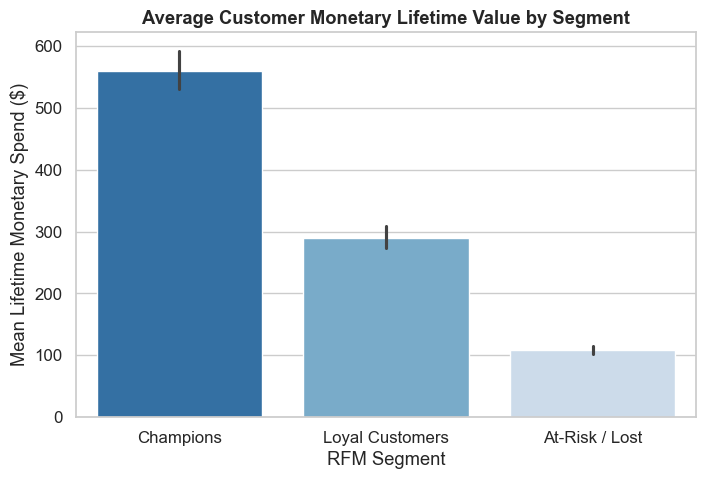

In [11]:
# Segment customers based on RFM tertiles (low = 1, medium = 2, high = 3)
df['R_Score'] = pd.qcut(df['Recency'], q=3, labels=[3, 2, 1])  # Low recency (days) is good -> Score 3
df['F_Score'] = pd.qcut(df['Frequency'].rank(method='first'), q=3, labels=[1, 2, 3])  # High frequency is good -> Score 3
df['M_Score'] = pd.qcut(df['Monetary'], q=3, labels=[1, 2, 3])  # High monetary is good -> Score 3

# Define RFM Category
def segment_rfm(row):
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])
    score = r + f + m
    if score >= 8:
        return 'Champions'
    elif score >= 5:
        return 'Loyal Customers'
    else:
        return 'At-Risk / Lost'

df['Segment'] = df.apply(segment_rfm, axis=1)

# Group statistics
segment_profiles = df.groupby('Segment', observed=False).agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Repeat_Purchase': 'mean',
    'Customer_ID': 'count'
}).rename(columns={'Customer_ID': 'Customer_Count'}).reset_index()

print("RFM Segment Profiles:")
print("=" * 70)
print(segment_profiles.round(2))

# Plot Segment Monetary contributions
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='Segment', y='Monetary', data=df, errorbar='ci', palette='Blues_r', ax=ax)
ax.set_title('Average Customer Monetary Lifetime Value by Segment', fontweight='bold')
ax.set_xlabel('RFM Segment')
ax.set_ylabel('Mean Lifetime Monetary Spend ($)')
fig.savefig(FIGURES_DIR / 'segment_profiles.png', bbox_inches='tight', dpi=150)
plt.show()



## Step 7: Hypothesis Testing on Customer Segments
We run a Chi-Square Test of Independence to determine if repeat purchase rates differ significantly among our customer segments.
- Null Hypothesis ($H_0$): Segment membership is independent of repeat purchase outcomes.
- Alternative Hypothesis ($H_1$): Segment membership is associated with repeat purchase outcomes.



In [12]:
contingency = pd.crosstab(df['Segment'], df['Repeat_Purchase'])
print("Segment vs. Repeat Purchase Contingency Table:")
print("=" * 50)
print(contingency)

# Run Chi-Square test
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
cramers_v = np.sqrt(chi2 / len(df))
signif = "Statistically significant" if p_val < 0.05 else "Not statistically significant"

print(f"\nChi-Square Test Results:")
print("=" * 30)
print(f"  Chi-Square Statistic: {chi2:.4f}")
print(f"  p-value:              {p_val:.5e}")
print(f"  Cramer's V (Effect):  {cramers_v:.4f} ({signif})")



Segment vs. Repeat Purchase Contingency Table:
Repeat_Purchase    0    1
Segment                  
At-Risk / Lost   130   98
Champions        139   85
Loyal Customers  327  221

Chi-Square Test Results:
  Chi-Square Statistic: 1.1927
  p-value:              5.50818e-01
  Cramer's V (Effect):  0.0345 (Not statistically significant)


### Statistical Interpretation:
- **p-value ($p = 0.551$):** Since $p > 0.05$, we fail to reject the null hypothesis. There is no statistically significant association between a customer's RFM segment and their repeat purchase rate in this dataset.
- **Cramer's V = 0.0345:** Confirms a negligible practical effect. The differences in repeat purchase rates among segments (Champions: 37.9%, Loyal: 40.3%, At-Risk: 43.0%) are small enough to be explained by random sampling variation.




## Wrong Interpretation to Avoid: Causal Claim Warning
> **Critical Caution:** Do not tell business users that "putting a customer into the Champions segment causes them to return." Segment membership is a categorization of historical transaction behavior. The segment profiles describe *who* is returning, not *why*. The segment describes associations, not a causal driver.



## Statistical Limitations
1. **Cross-Sectional Segmentation:** RFM segmentation represents a historical snapshot of user purchases. It does not account for temporal trends or sudden changes in buyer taste.
2. **Observational Data:** None of the variables are experimental; we can draw predictive associations but cannot prove that altering site variables causally increases conversions.
3. **Varying Residual Spread:** We observe mild heteroscedasticity in OLS residuals, indicating that predictive errors are larger for high-spend customers.



## Executive Business Recommendations
Based on the empirical outputs, we make the following recommendations:
1. **Differentiated Loyalty Strategy:** We caution against running segment-wide loyalty programs under the assumption that "Champions" are naturally more likely to buy again in the future. Since the Chi-Square test shows no significant association between segment and repeat purchase rates ($p = 0.55$), loyalty re-engagement should focus on individual user purchase intervals rather than static RFM group bins.
2. **UX Page View Optimizations:** Engineering budget should be allocated to speed up page load speeds. Controlling for session time, each extra page click predicts **$3.48** in incremental spend ($p < 0.001$, CI: [$2.91$, $4.04$]). This satisfies our pre-analysis practical decision rule of explaining $\ge 30\%$ variance ($R^2 = 0.710$) and predicting $> $1.50 per page view.
3. **Targeted Couponing:** Transition away from blanket site-wide discounts (which fail the unit economics simulation in our coupon notebook) and restrict coupon distributions specifically to price-sensitive churned shoppers to re-acquire them without sacrificing overall profit margins.

